# Data analytics on trade data
### In this analysis we are going to describe the behaviour of muliple trading plans.


In [1]:
# IMPORT PANDAS
import pandas as pd

# IMPORT NUMPY
import numpy as np

# IMPORT NATPLOTLIB
import matplotlib.pyplot as plt

# IMPORT SEABORN
import seaborn as sns

### LOAD THE DATA SET

In [2]:
df_trade_data = pd.read_csv("trade_data.csv")

### Data Overview

In [3]:
# Show first five observations of the data
df_trade_data.head()

,HSCode,type,Commodity,value,country,year,trade_value,quantity,unit_price,shipping_cost,tax,duty
0,2,Export,MEAT AND EDIBLE MEAT OFFAL.,0.18,AFGHANISTAN TIS,2018,38079.47,3,12693.16,9054.39,4683.36,1362.03
1,3,Export,"FISH AND CRUSTACEANS, MOLLUSCS AND OTHER AQUAT...",0.00,AFGHANISTAN TIS,2018,95120.72,461,206.34,154.89,5287.75,8875.51
2,4,Export,DAIRY PRODUCE; BIRDS' EGGS; NATURAL HONEY; EDI...,12.48,AFGHANISTAN TIS,2018,73467.40,5,14693.48,5948.07,4867.17,6827.14
3,6,Export,LIVE TREES AND OTHER PLANTS; BULBS; ROOTS AND ...,0.00,AFGHANISTAN TIS,2018,60267.19,14,4304.80,7335.05,8964.37,4369.10
4,7,Export,EDIBLE VEGETABLES AND CERTAIN ROOTS AND TUBERS.,1.89,AFGHANISTAN TIS,2018,16445.85,482,34.12,9840.70,1248.63,1616.67


In [4]:
# Show last five observations of the data
df_trade_data.tail()

,HSCode,type,Commodity,value,country,year,trade_value,quantity,unit_price,shipping_cost,tax,duty
213142,81,Import,OTHER BASE METALS; CERMETS; ARTICLES THEREOF.,0.14,ZIMBABWE,2010,51205.04,156,328.24,3759.79,6629.44,2116.54
213143,82,Import,"TOOLS IMPLEMENTS, CUTLERY, SPOONS AND FORKS, O...",0.00,ZIMBABWE,2010,40865.13,146,279.90,2184.47,3806.54,3855.32
213144,84,Import,"NUCLEAR REACTORS, BOILERS, MACHINERY AND MECHA...",NaN,ZIMBABWE,2010,41407.16,158,262.07,8656.33,2888.38,2207.66
213145,85,Import,ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS T...,NaN,ZIMBABWE,2010,14402.78,237,60.77,3690.04,1113.21,949.63
213146,99,Import,MISCELLANEOUS GOODS.,NaN,ZIMBABWE,2010,17311.08,190,91.11,7952.22,2227.91,1240.55


In [5]:
# Show the shape of the data
# shape is a keyword not a function
df_trade_data.shape

(213147, 12)

**Interpretation**
 - We have 213147 observations (Rows)
 - We have 12 attributes (Columns)

In [6]:
# Show the basic info of the data
df_trade_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213147 entries, 0 to 213146
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   HSCode         213147 non-null  int64  
 1   type           213147 non-null  object 
 2   Commodity      213147 non-null  object 
 3   value          187521 non-null  float64
 4   country        213147 non-null  object 
 5   year           213147 non-null  int64  
 6   trade_value    213147 non-null  float64
 7   quantity       213147 non-null  int64  
 8   unit_price     213147 non-null  float64
 9   shipping_cost  213147 non-null  float64
 10  tax            213147 non-null  float64
 11  duty           213147 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 19.5+ MB


In [7]:
# Justify the basic statistics of the data
# T means transpose
df_trade_data.describe().T

,count,mean,std,min,25%,50%,75%,max
HSCode,213147.0,52.249846,27.877911,1.00,29.00,53.00,75.000,99.00
value,187521.0,35.607086,433.335357,0.00,0.03,0.36,4.050,32781.57
year,213147.0,2014.042731,2.579942,2010.00,2012.00,2014.00,2016.000,2018.00
trade_value,213147.0,50512.592717,28569.510216,1000.47,25717.83,50589.92,75226.030,99999.21
quantity,213147.0,250.676026,144.290385,1.00,126.00,251.00,376.000,500.00
unit_price,213147.0,689.124882,3304.454811,2.06,102.56,201.69,400.820,99614.99
shipping_cost,213147.0,5053.132325,2854.710119,100.01,2582.06,5059.64,7521.095,9999.98
tax,213147.0,5050.602347,3309.581993,52.03,2347.84,4599.52,7257.645,14957.67
duty,213147.0,3033.304680,2177.299272,20.96,1282.46,2555.43,4413.585,9986.18


In [8]:
## Data Pre-Processing

In [9]:
# Null value handling
# Show the count of null records in the data
df_trade_data.isnull()

,HSCode,type,Commodity,value,country,year,trade_value,quantity,unit_price,shipping_cost,tax,duty
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
213142,False,False,False,False,False,False,False,False,False,False,False,False
213143,False,False,False,False,False,False,False,False,False,False,False,False
213144,False,False,False,True,False,False,False,False,False,False,False,False
213145,False,False,False,True,False,False,False,False,False,False,False,False


In [10]:
df_trade_data.isnull().sum()

HSCode               0
type                 0
Commodity            0
value            25626
country              0
year                 0
trade_value          0
quantity             0
unit_price           0
shipping_cost        0
tax                  0
duty                 0
dtype: int64

**Interpretation**
 - We have 25626 null records in value attribute.

In [11]:
# Find the percentage of missing records
df_trade_data.isnull().sum() / len(df_trade_data) * 100

HSCode            0.000000
type              0.000000
Commodity         0.000000
value            12.022689
country           0.000000
year              0.000000
trade_value       0.000000
quantity          0.000000
unit_price        0.000000
shipping_cost     0.000000
tax               0.000000
duty              0.000000
dtype: float64

In [12]:
# Drop the null records from the dataframe
df_trade_data.dropna(inplace=True)

In [13]:
# Do the authentic check
df_trade_data.isnull().sum()

HSCode           0
type             0
Commodity        0
value            0
country          0
year             0
trade_value      0
quantity         0
unit_price       0
shipping_cost    0
tax              0
duty             0
dtype: int64

### Data pre-processing is done

# EDA - Exploratory data analytics

# Univariate Analysis

In [14]:
# segrigate the data based on datatype
df_num = df_trade_data.select_dtypes(include="number")  # numerical data frame
df_cat = df_trade_data.select_dtypes(include="object")  # categarical data fram

### Numerical columns Analysis

In [15]:
# show the numerical column
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### HSCode

In [16]:
# Show the minimum age
df_num.HSCode.min()

np.int64(1)

In [17]:
# Show the maximum age
df_num.HSCode.max()

np.int64(99)

In [18]:
# Show the average
df_num.HSCode.mean()

np.float64(52.10141797452019)

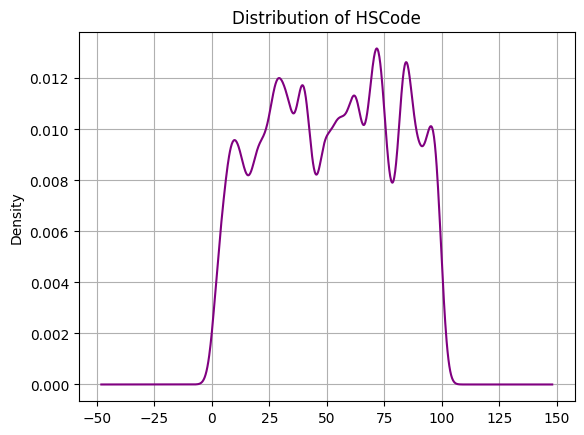

In [19]:
# Show the distribution of the single numerical column
df_num.HSCode.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of HSCode")
plt.show()

**Interpretation**
 - Minimum HSCode of the person in the data is 1.
 - Maximum HSCode of the person in the data is 99.
 - Average HSCode of the person in the data is 52.24.
 - The data follows multimodel distribution.

In [20]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### Value

In [21]:
# Show the minimum age
df_num.value.min()

np.float64(0.0)

In [22]:
# Show the maximum age
df_num.value.max()

np.float64(32781.57)

In [23]:
# Show the average
df_num.value.mean()

np.float64(35.60708608635832)

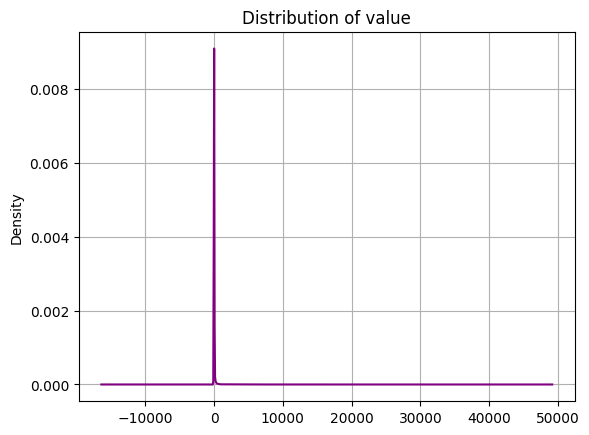

In [24]:
# Show the distribution of the single numerical column
df_num.value.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of value")
plt.show()

**Interpretation**
 - Minimum value in the data is 0.
 - Maximum value in the data is 32781.57.
 - Average value in the data is 35.607.

In [25]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### trade_value

In [26]:
# Show the minimum age
df_num.trade_value.min()

np.float64(1000.47)

In [27]:
# Show the minimum age
df_num.trade_value.max()

np.float64(99999.21)

In [28]:
# Show the minimum age
df_num.trade_value.mean()

np.float64(50497.53675583002)

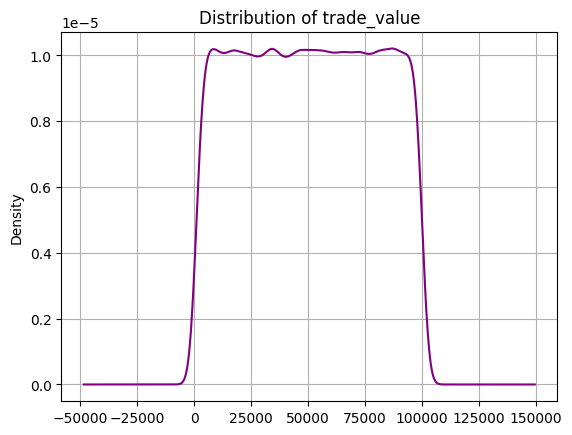

In [29]:
# Show the distribution of the single numerical column
df_num.trade_value.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of trade_value")
plt.show()

**Interpretation**
 - Minimum trade_value in the data is 1000.27.
 - Maximum trade_value in the data is 99999.21.
 - Average trade_value in the data is 50512.59271685737`.
 - The data follows multimodel distribution.

In [30]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### quantity

In [31]:
# Show the minimum age
df_num.quantity.min()

np.int64(1)

In [32]:
# Show the minimum age
df_num.quantity.max()

np.int64(500)

In [33]:
# Show the minimum age
df_num.quantity.mean()

np.float64(250.6667893195962)

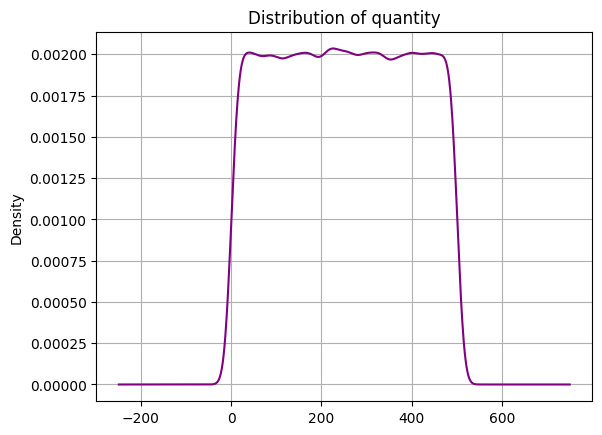

In [34]:
# Show the distribution of the single numerical column
df_num.quantity.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of quantity")
plt.show()

**Interpretation**
 - Minimum quantity in the data is 1.
 - Maximum quantity in the data is 500.
 - Average quantity in the data is 250.67602640431252.
 - The data follows multimodel distribution.

In [35]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### unit_price

In [36]:
# Show the minimum age
df_num.unit_price.min()

np.float64(2.06)

In [37]:
# Show the minimum age
df_num.unit_price.max()

np.float64(99614.99)

In [38]:
# Show the minimum age
df_num.unit_price.mean()

np.float64(687.6116648802)

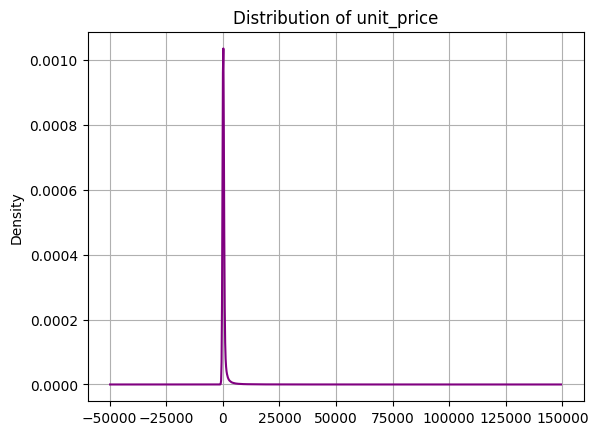

In [39]:
# Show the distribution of the single numerical column
df_num.unit_price.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of unit_price")
plt.show()

**Interpretation**

 - Minimum unit_price in the data is 2.
 - Maximum unit_price in the data is 99614.
 - Average unit_price in the data is 689.1248821236047.

In [40]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### shipping_cost

In [41]:
# Show the minimum age
df_num.shipping_cost.min()

np.float64(100.01)

In [42]:
# Show the minimum age
df_num.shipping_cost.max()

np.float64(9999.98)

In [43]:
# Show the minimum age
df_num.shipping_cost.mean()

np.float64(5053.413814666091)

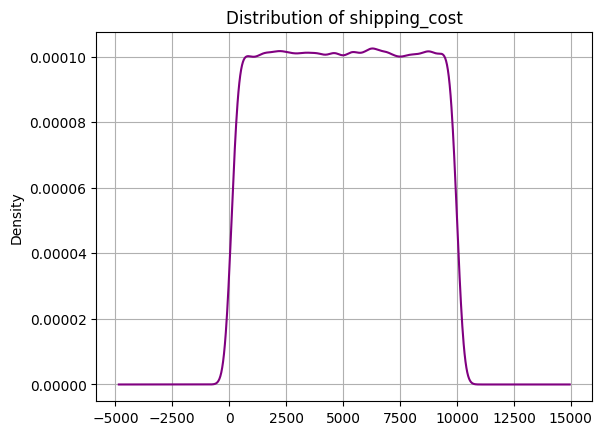

In [44]:
# Show the distribution of the single numerical column
df_num.shipping_cost.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of shipping_cost")
plt.show()

**Interpretation**

 - Minimum shipping_cost in the data is 100.01.
 - Maximum shipping_cost in the data is 9999.98.
 - Average shipping_cost in the data is 5053.132324639802.
 - The data follows multimodel distribution.

In [45]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### tax

In [46]:
# Show the minimum age
df_num.tax.min()

np.float64(52.03)

In [47]:
# Show the minimum age
df_num.tax.max()

np.float64(14957.67)

In [48]:
# Show the minimum age
df_num.tax.mean()

np.float64(5047.068555308472)

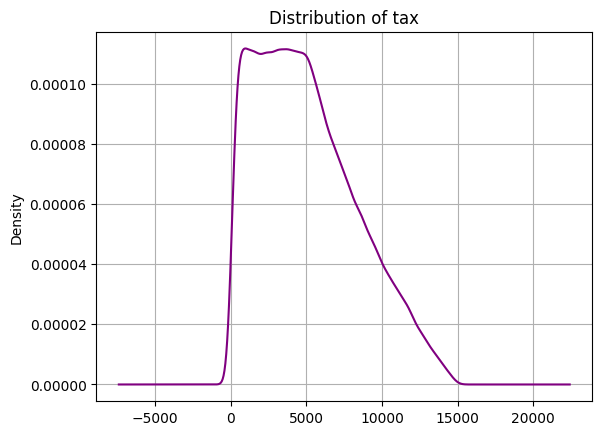

In [49]:
# Show the distribution of the single numerical column
df_num.tax.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of tax")
plt.show()

**Interpretation**

 - Minimum tax in the data is 52.03.
 - Maximum tax in the data is 14957.67.
 - Average tax in the data is 5050.602346549565.
 - The data follows multimodel distribution.

In [50]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

#### duty

In [51]:
# Show the minimum age
df_num.duty.min()

np.float64(20.96)

In [52]:
# Show the minimum age
df_num.duty.max()

np.float64(9986.18)

In [53]:
# Show the minimum age
df_num.duty.mean()

np.float64(3031.500477546515)

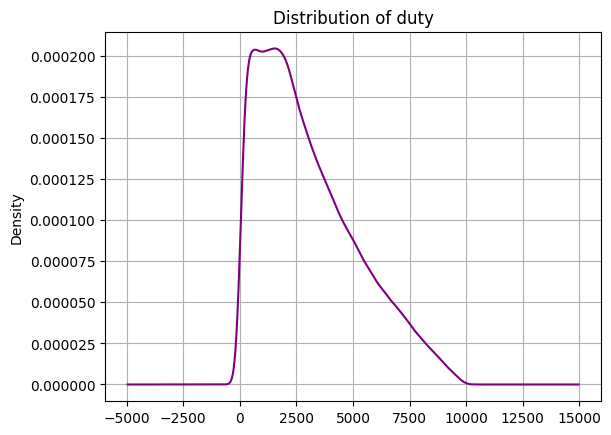

In [54]:
# Show the distribution of the single numerical column
df_num.duty.plot(kind="kde", color="purple")  # Kernal Density Plot
plt.grid()
plt.title("Distribution of duty")
plt.show()

**Interpretation**

 - Minimum duty in the data is 20.96.
 - Maximum duty in the data is 9986.18.
 - Average duty in the data is 3033.3046796342433.
 - The data follows multimodel distribution.

### Categorical columns Analysis

In [55]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

#### type

In [56]:
# Find the count
df_cat.type.value_counts()

type
Export    122985
Import     64536
Name: count, dtype: int64

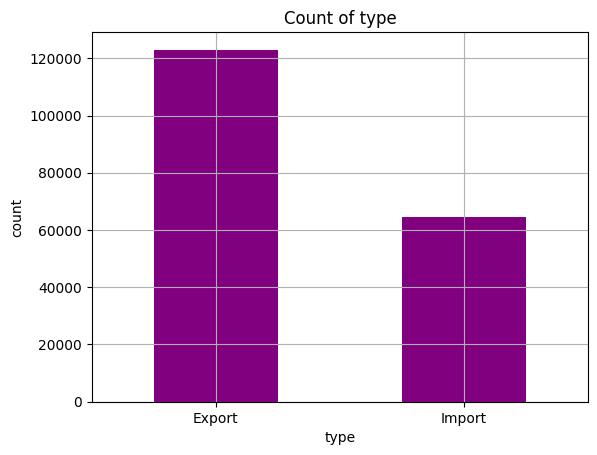

In [57]:
# Show the plot
df_cat.type.value_counts().plot(kind="bar", color="purple")
plt.grid()
plt.title("Count of type")
plt.xticks(rotation=0)
plt.ylabel("count")
plt.show()

**Interpretation**
 - We have count of supply exported is  137023.
 - We have count of supply imported is   76124.

In [58]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

#### Commodity

In [59]:
# Find the count
df_cat.Commodity.value_counts()

Commodity
ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS,AND PARTS.    3454
NUCLEAR REACTORS, BOILERS, MACHINERY AND MECHANICAL APPLIANCES; PARTS THEREOF.                                                                            3386
PLASTIC AND ARTICLES THEREOF.                                                                                                                             3104
OPTICAL, PHOTOGRAPHIC CINEMATOGRAPHIC MEASURING, CHECKING PRECISION, MEDICAL OR SURGICAL INST. AND APPARATUS PARTS AND ACCESSORIES THEREOF;               3052
IRON AND STEEL                                                                                                                                            2960
                                                                                                                                                          ... 
MEAT AND EDIBLE MEAT OFFAL.         

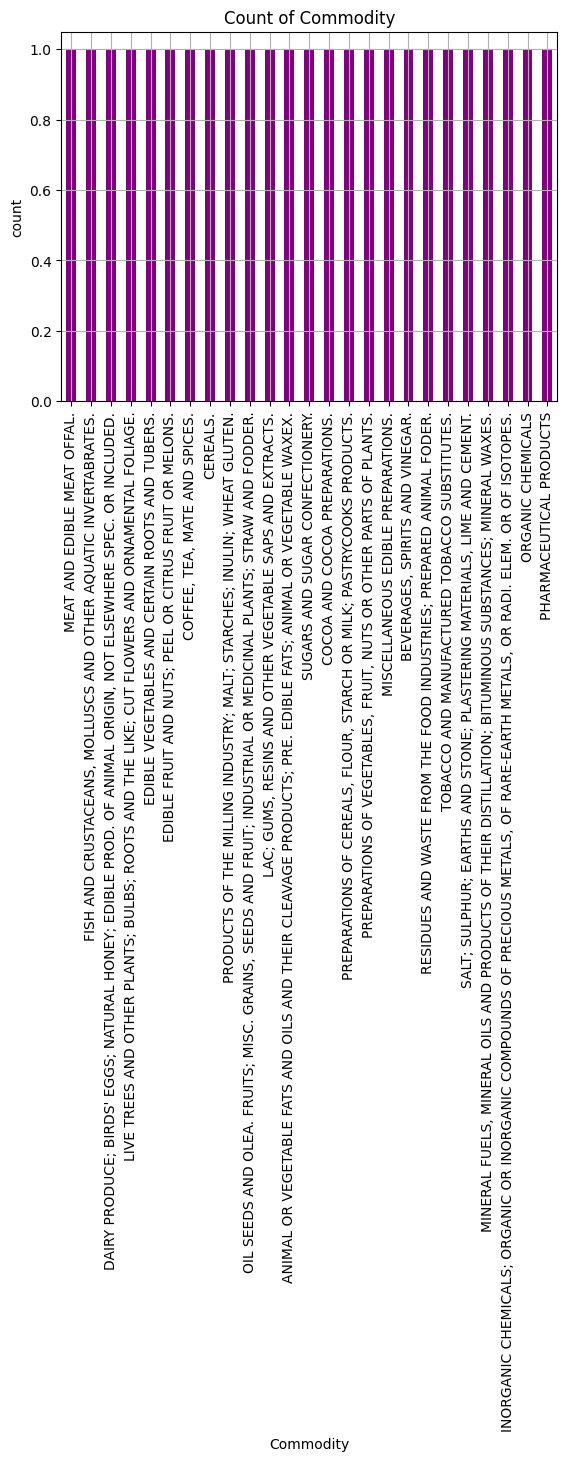

In [60]:
# Show the plot
df_cat.Commodity.head(25).value_counts().plot(kind="bar", color="purple")
plt.grid()
plt.title("Count of Commodity")
plt.xticks(rotation=90)
plt.ylabel("count")
plt.show()

**Interpretation**
 - We have the count of ELECTRICAL MACHINERY AND EQUIPMENT AND PARTS THEREOF; SOUND RECORDERS AND REPRODUCERS, TELEVISION IMAGE AND SOUND RECORDERS AND REPRODUCERS,AND PARTS is 3741.
 - We have the count of NUCLEAR REACTORS, BOILERS, MACHINERY AND MECHANICAL APPLIANCES; PARTS THEREOF is 3656
 - We have the count of PLASTIC AND ARTICLES THEREOF is 3397
 - We have the count of MISCELLANEOUS GOODS is 3389
 - We have the count of OPTICAL, PHOTOGRAPHIC CINEMATOGRAPHIC MEASURING, CHECKING PRECISION, MEDICAL OR SURGICAL INST. AND APPARATUS PARTS AND ACCESSORIES THEREOF is 3335
 - We have the count of TIN AND ARTICLES THEREOF is 969
 - We have the count of LIVE ANIMALS is 948
 - We have the count of MEAT AND EDIBLE MEAT OFFAL is 901
 - We have the count of FURSKINS AND ARTIFICIAL FUR, MANUFACTURES THEREOF is 900
 - We have the count of CORK AND ARTICLES OF CORK is 896


In [61]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

#### country

In [62]:
# Find the count
df_cat.country.value_counts()

country
U S A                                       1750
AUSTRALIA                                   1748
BELGIUM                                     1745
GERMANY                                     1736
U K                                         1734
                                            ... 
CHANNEL IS                                     4
INSTALLATIONS IN INTERNATIONAL WATERS          3
SINT MAARTEN (DUTCH PART)                      2
CURACAO                                        2
JERSEY                                         2
Name: count, Length: 248, dtype: int64

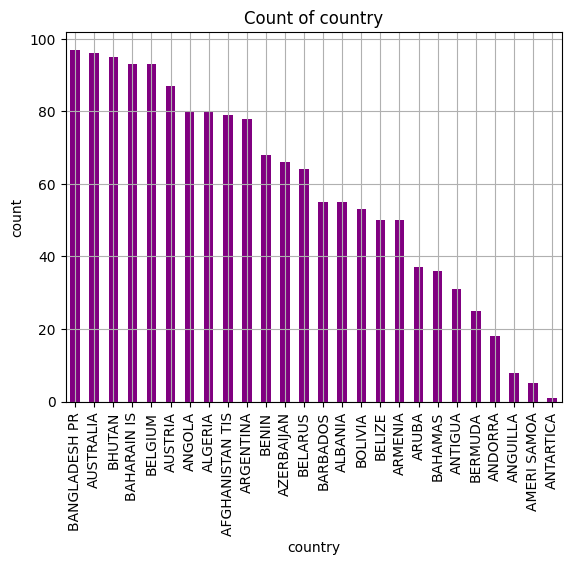

In [63]:
df_cat.country.head(1500).value_counts().plot(kind="bar", color="purple")
plt.grid()
plt.title("Count of country")
plt.xticks(rotation=90)
plt.ylabel("count")
plt.show()

In [64]:
df_trade_data.columns

Index(['HSCode', 'type', 'Commodity', 'value', 'country', 'year',
       'trade_value', 'quantity', 'unit_price', 'shipping_cost', 'tax',
       'duty'],
      dtype='object')

### Bivariate Analysis

In [65]:
df_trade_data.head()

,HSCode,type,Commodity,value,country,year,trade_value,quantity,unit_price,shipping_cost,tax,duty
0,2,Export,MEAT AND EDIBLE MEAT OFFAL.,0.18,AFGHANISTAN TIS,2018,38079.47,3,12693.16,9054.39,4683.36,1362.03
1,3,Export,"FISH AND CRUSTACEANS, MOLLUSCS AND OTHER AQUAT...",0.00,AFGHANISTAN TIS,2018,95120.72,461,206.34,154.89,5287.75,8875.51
2,4,Export,DAIRY PRODUCE; BIRDS' EGGS; NATURAL HONEY; EDI...,12.48,AFGHANISTAN TIS,2018,73467.40,5,14693.48,5948.07,4867.17,6827.14
3,6,Export,LIVE TREES AND OTHER PLANTS; BULBS; ROOTS AND ...,0.00,AFGHANISTAN TIS,2018,60267.19,14,4304.80,7335.05,8964.37,4369.10
4,7,Export,EDIBLE VEGETABLES AND CERTAIN ROOTS AND TUBERS.,1.89,AFGHANISTAN TIS,2018,16445.85,482,34.12,9840.70,1248.63,1616.67


In [66]:
df_num.corr()

,HSCode,value,year,trade_value,quantity,unit_price,shipping_cost,tax,duty
HSCode,1.000000,-0.000539,-0.009309,-0.003255,0.001820,-0.001532,0.003450,-0.002351,-0.002813
value,-0.000539,1.000000,0.000617,-0.000677,0.000102,-0.002247,0.001391,0.000832,-0.000342
year,-0.009309,0.000617,1.000000,0.003755,-0.001884,0.000619,-0.000528,0.003165,0.003640
trade_value,-0.003255,-0.000677,0.003755,1.000000,0.001889,0.120159,-0.001183,0.862962,0.787872
quantity,0.001820,0.000102,-0.001884,0.001889,1.000000,-0.256346,0.004034,-0.000622,0.002680
unit_price,-0.001532,-0.002247,0.000619,0.120159,-0.256346,1.000000,-0.002442,0.103378,0.094699
shipping_cost,0.003450,0.001391,-0.000528,-0.001183,0.004034,-0.002442,1.000000,-0.002009,-0.000384
tax,-0.002351,0.000832,0.003165,0.862962,-0.000622,0.103378,-0.002009,1.000000,0.680160
duty,-0.002813,-0.000342,0.003640,0.787872,0.002680,0.094699,-0.000384,0.680160,1.000000


**Interpretation**
 - We have correlation between tax and trade_value.
 - We have correlation between duty and trade_value.

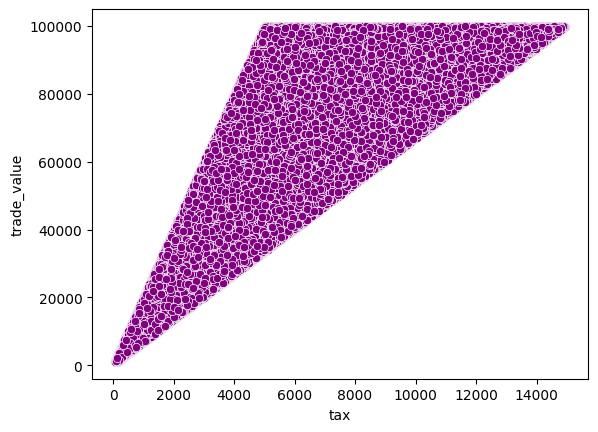

In [67]:
sns.scatterplot(x="tax", y="trade_value", data=df_trade_data, color="purple")
plt.show()

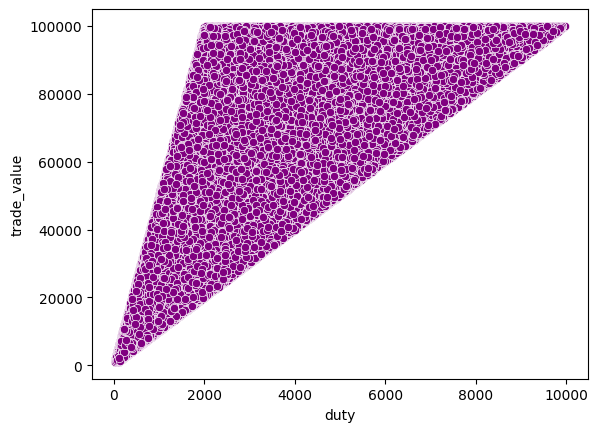

In [68]:
sns.scatterplot(x="duty", y="trade_value", data=df_trade_data, color="purple")
plt.show()

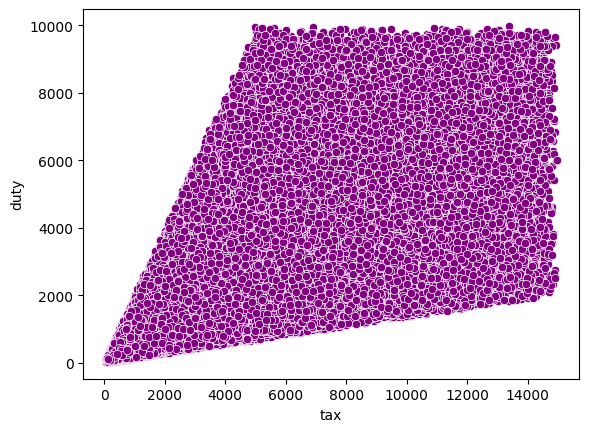

In [69]:
sns.scatterplot(x="tax", y="duty", data=df_trade_data, color="purple")
plt.show()

## Bivariate Analysis on one numerical and one categorical column

In [70]:
# Show all categorical columns
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [71]:
# show the numerical columns
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### type, HSCode

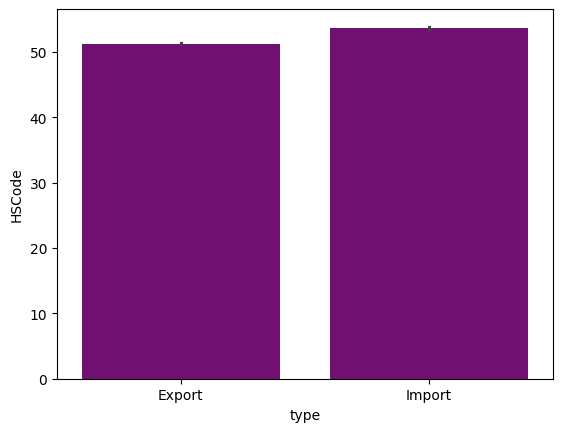

In [72]:
sns.barplot(df_trade_data, x="type", y="HSCode", color="purple")
plt.show()

**Interpretation**
 - The graph is quite balanced.

In [73]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [74]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### Commodity, HSCode

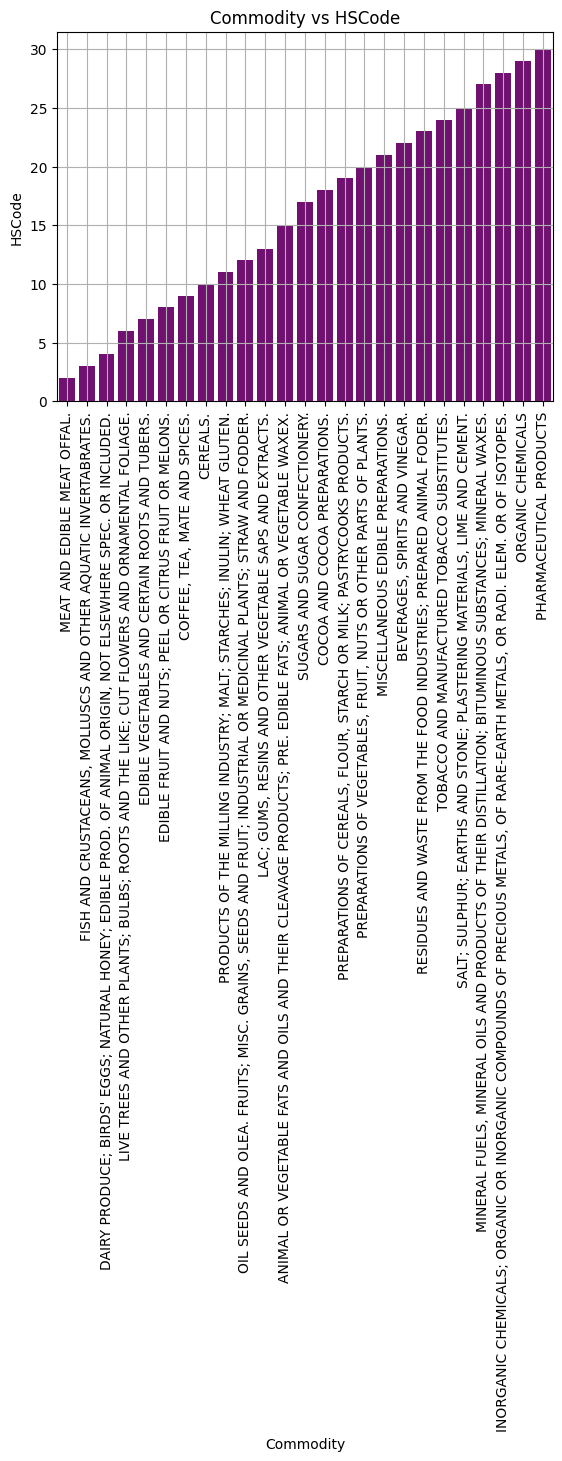

In [75]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="HSCode", color="purple")
plt.title("Commodity vs HSCode")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - No commodity has same Hscode.

In [76]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [77]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### country, HSCode

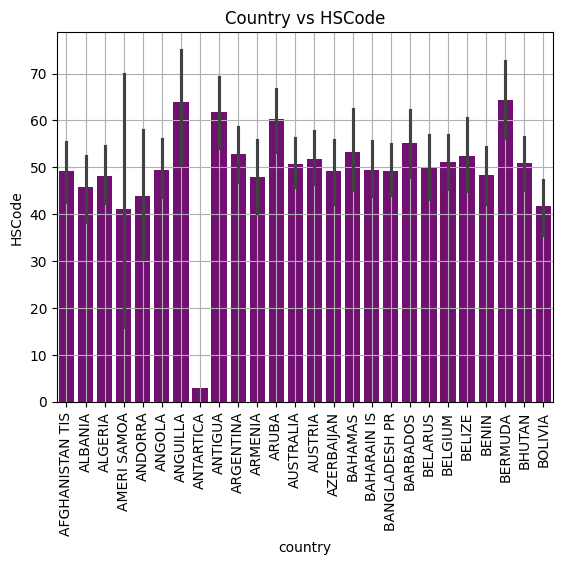

In [78]:
sns.barplot(df_trade_data.head(1500), x="country", y="HSCode", color="purple")
plt.title("Country vs HSCode")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - HSCode for Antartica is the least.

In [79]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [80]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### type, value

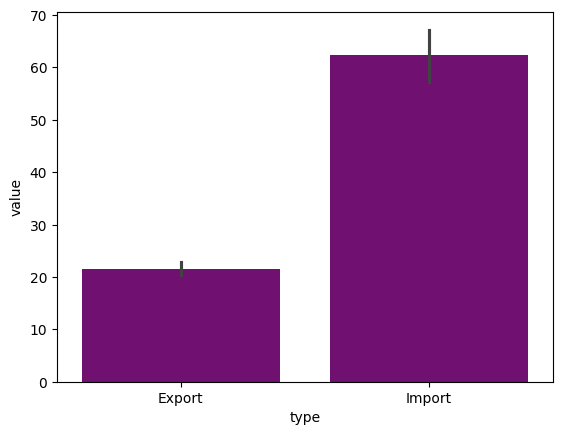

In [81]:
sns.barplot(df_trade_data, x="type", y="value", color="purple")
plt.show()

**Interpretation**
 - Value of import is more than of export.

In [82]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [83]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### Commodity, value

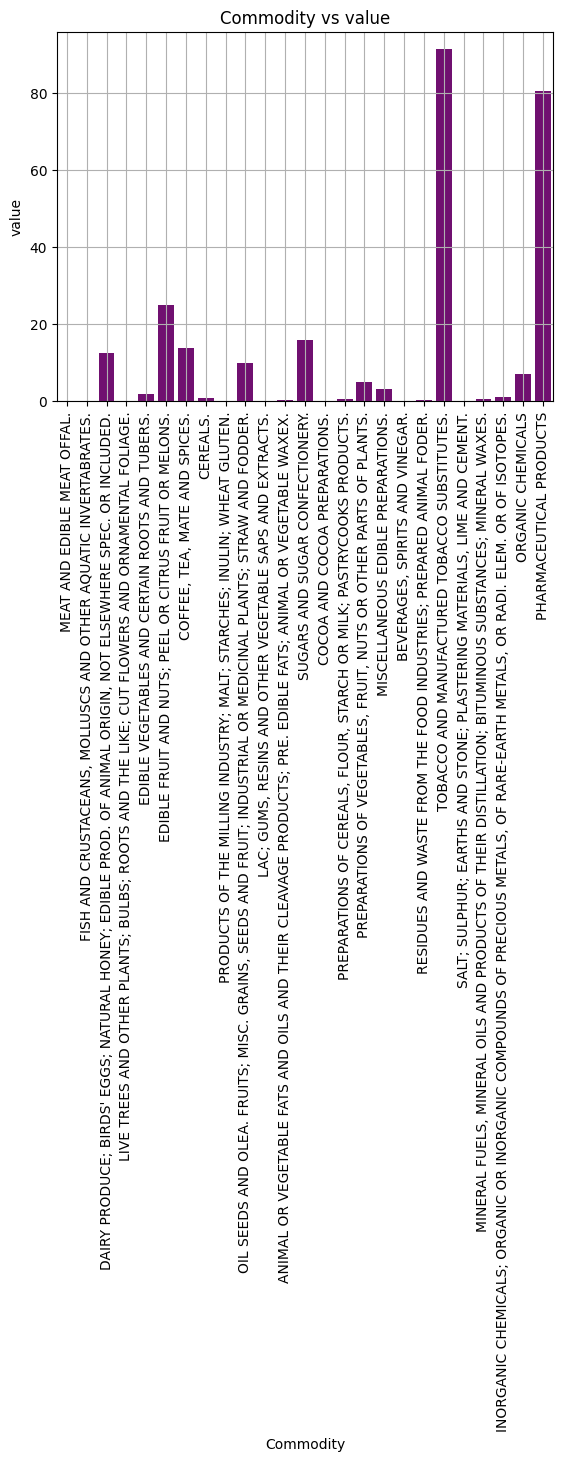

In [84]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="value", color="purple")
plt.title("Commodity vs value")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - There is much difference between values of each commodity.

In [85]:
df_cat.columns

Index(['type', 'Commodity', 'country'], dtype='object')

In [86]:
df_num.columns

Index(['HSCode', 'value', 'year', 'trade_value', 'quantity', 'unit_price',
       'shipping_cost', 'tax', 'duty'],
      dtype='object')

### country, value

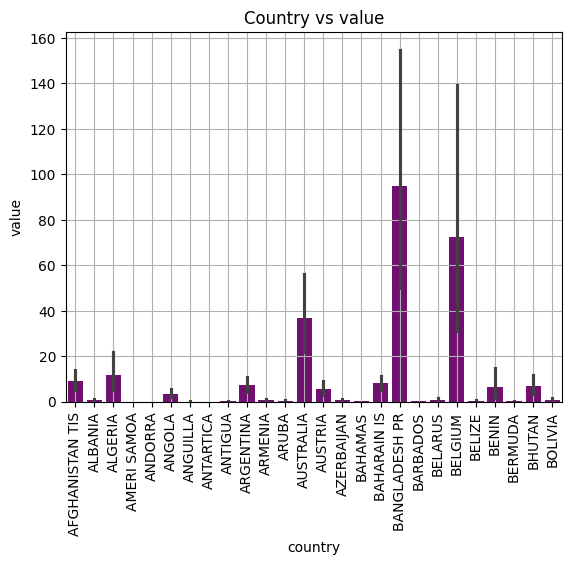

In [87]:
sns.barplot(df_trade_data.head(1500), x="country", y="value", color="purple")
plt.title("Country vs value")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Values of each country varies significantly.

### type, year

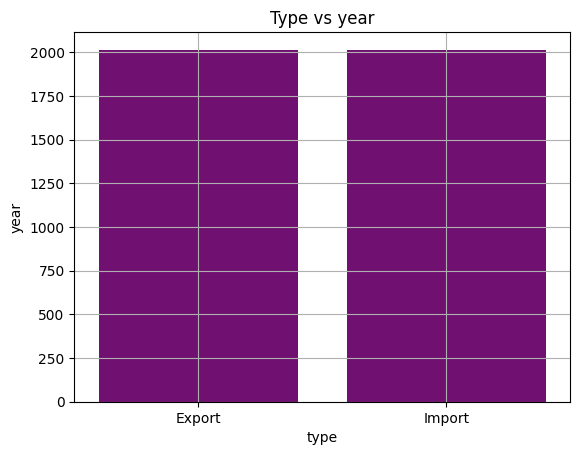

In [88]:
sns.barplot(df_trade_data, x="type", y="year", color="purple")
plt.title("Type vs year")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is balanced.

### type, trade_value

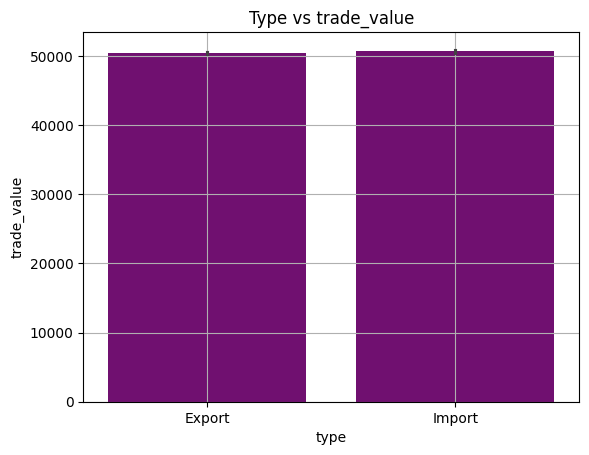

In [89]:
sns.barplot(df_trade_data, x="type", y="trade_value", color="purple")
plt.title("Type vs trade_value")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, trade_value

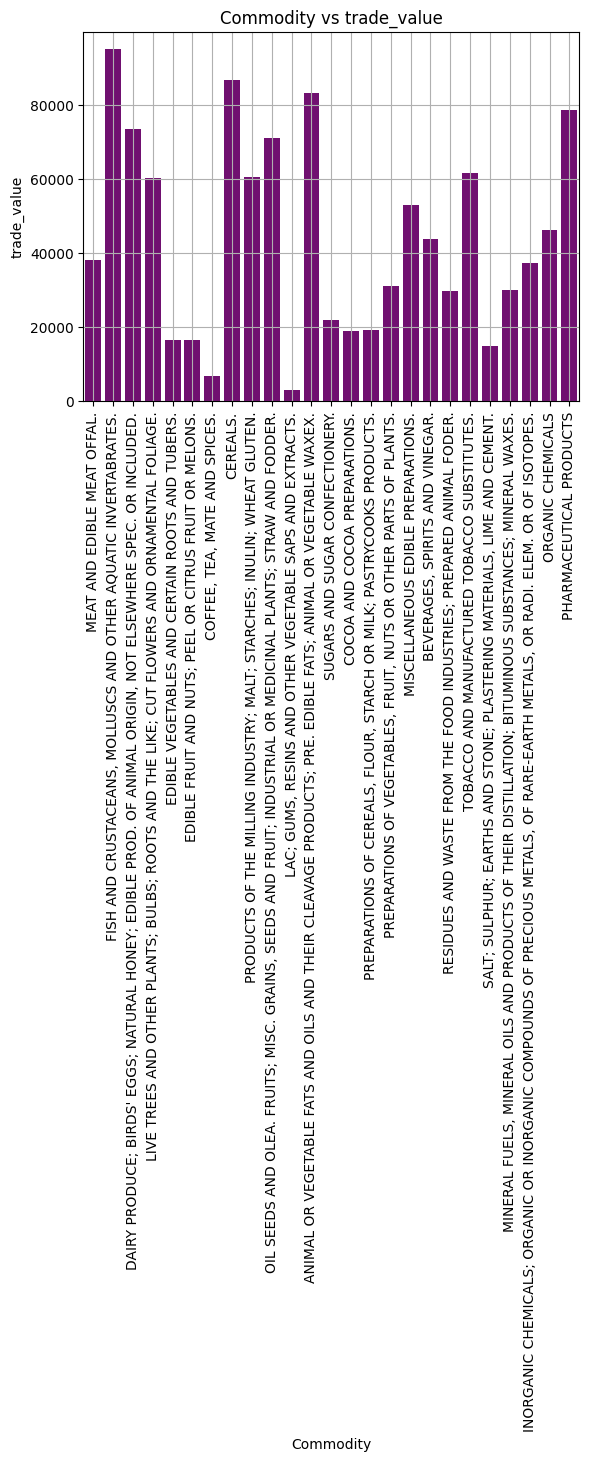

In [90]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="trade_value", color="purple")
plt.title("Commodity vs trade_value")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - The trade value of the commodity (Fish and Crustaceans,Molluscus and other Aquatic Invertebrates) is higher than others.

### country, trade_value

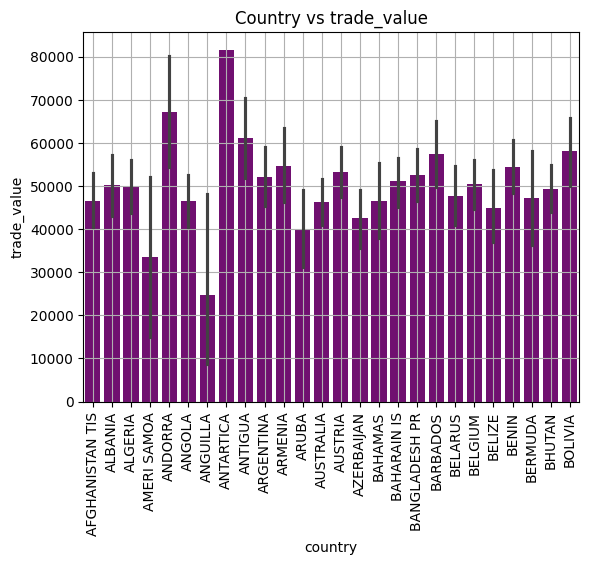

In [91]:
sns.barplot(df_trade_data.head(1500), x="country", y="trade_value", color="purple")
plt.title("Country vs trade_value")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Trade value of Anguilla is less.

### type, quantity

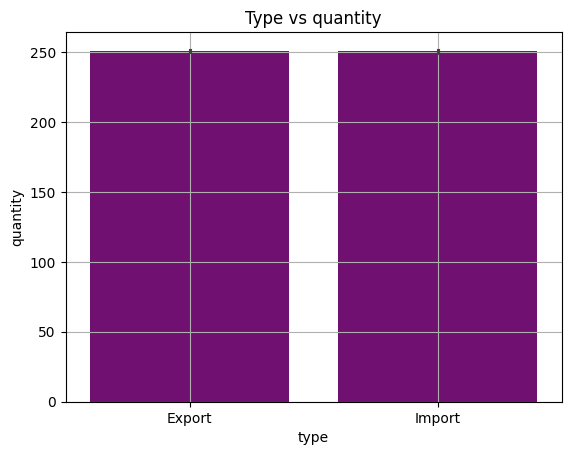

In [92]:
sns.barplot(df_trade_data, x="type", y="quantity", color="purple")
plt.title("Type vs quantity")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, quantity

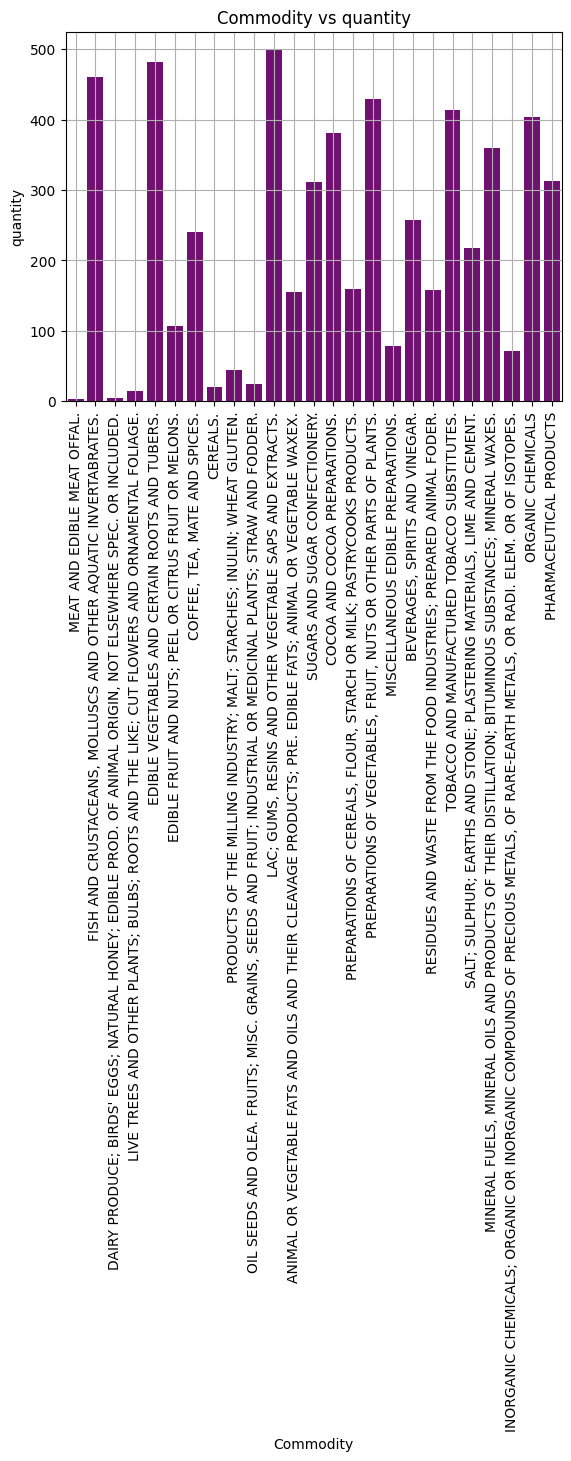

In [93]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="quantity", color="purple")
plt.title("Commodity vs quantity")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Quantity of Lac,gums,resins and other vegetable saps and extract is high.

### country, quantity

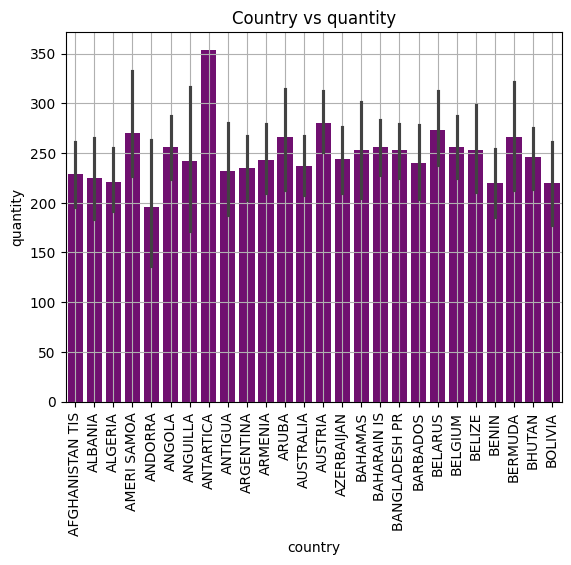

In [94]:
sns.barplot(df_trade_data.head(1500), x="country", y="quantity", color="purple")
plt.title("Country vs quantity")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Andorra has less quantity compare to other countries.

### type, unit_price

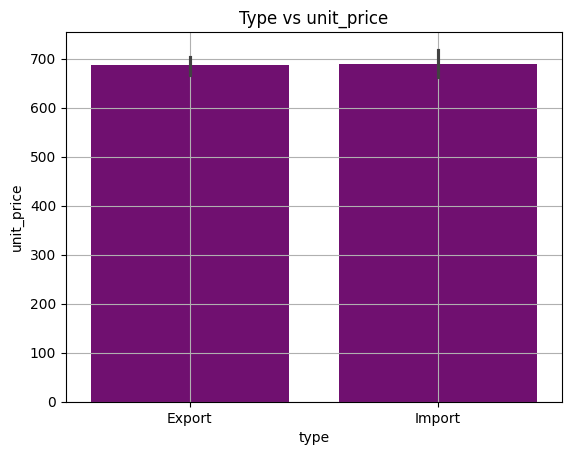

In [95]:
sns.barplot(df_trade_data, x="type", y="unit_price", color="purple")
plt.title("Type vs unit_price")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, unit_price

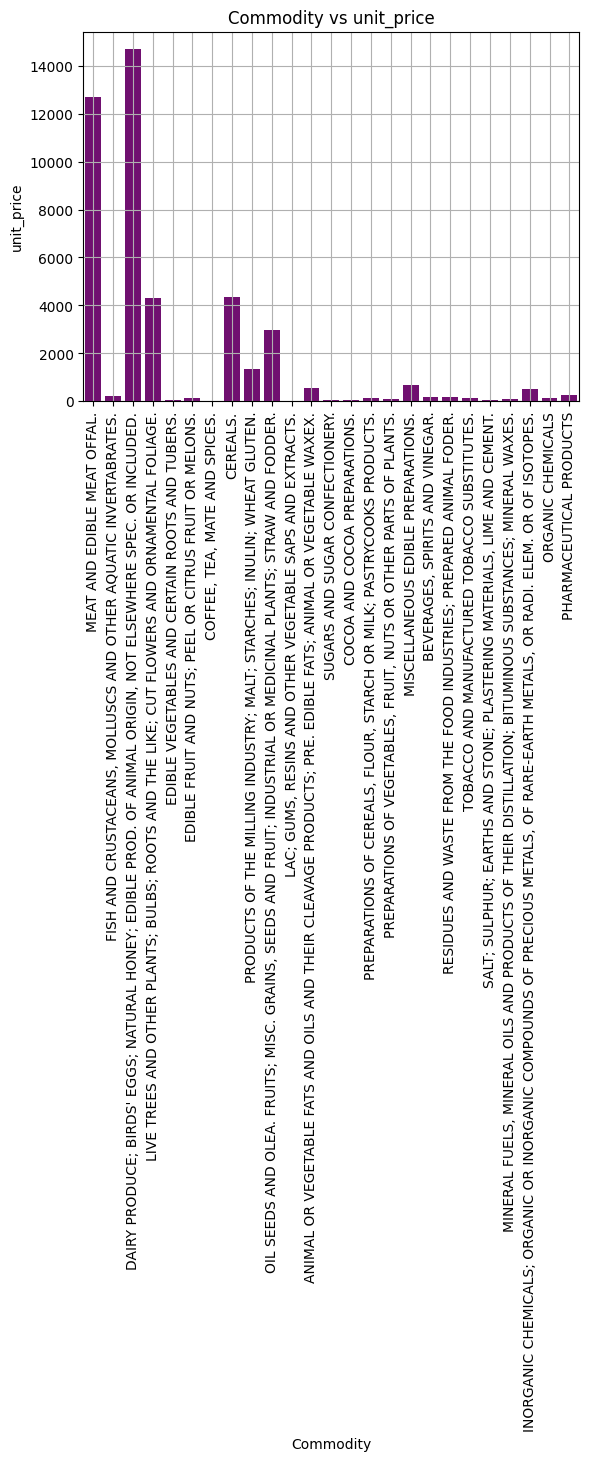

In [96]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="unit_price", color="purple")
plt.title("Commodity vs unit_price")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - There exists large variance of unit price between commodities.

### country, unit_price

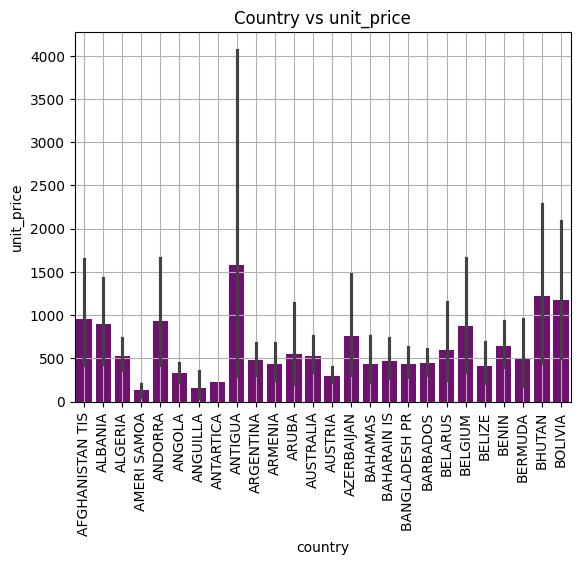

In [97]:
sns.barplot(
    df_trade_data.head(1500),
    x="country",
    y="unit_price",
    color="purple",
    estimator="mean",
)
plt.title("Country vs unit_price")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Antigua shows very large difference in it's average and maximum unit price.

### type, shipping_cost

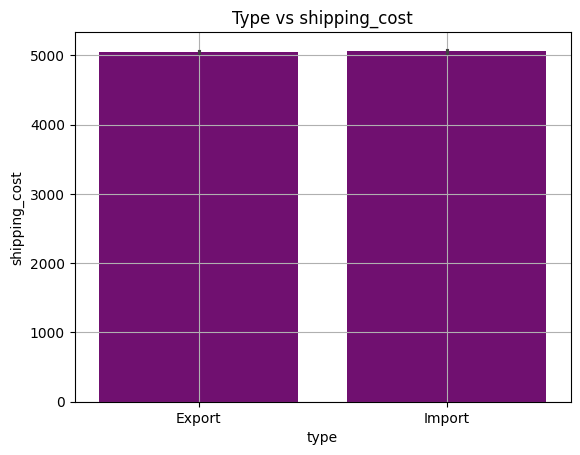

In [98]:
sns.barplot(df_trade_data, x="type", y="shipping_cost", color="purple")
plt.title("Type vs shipping_cost")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, shipping_cost

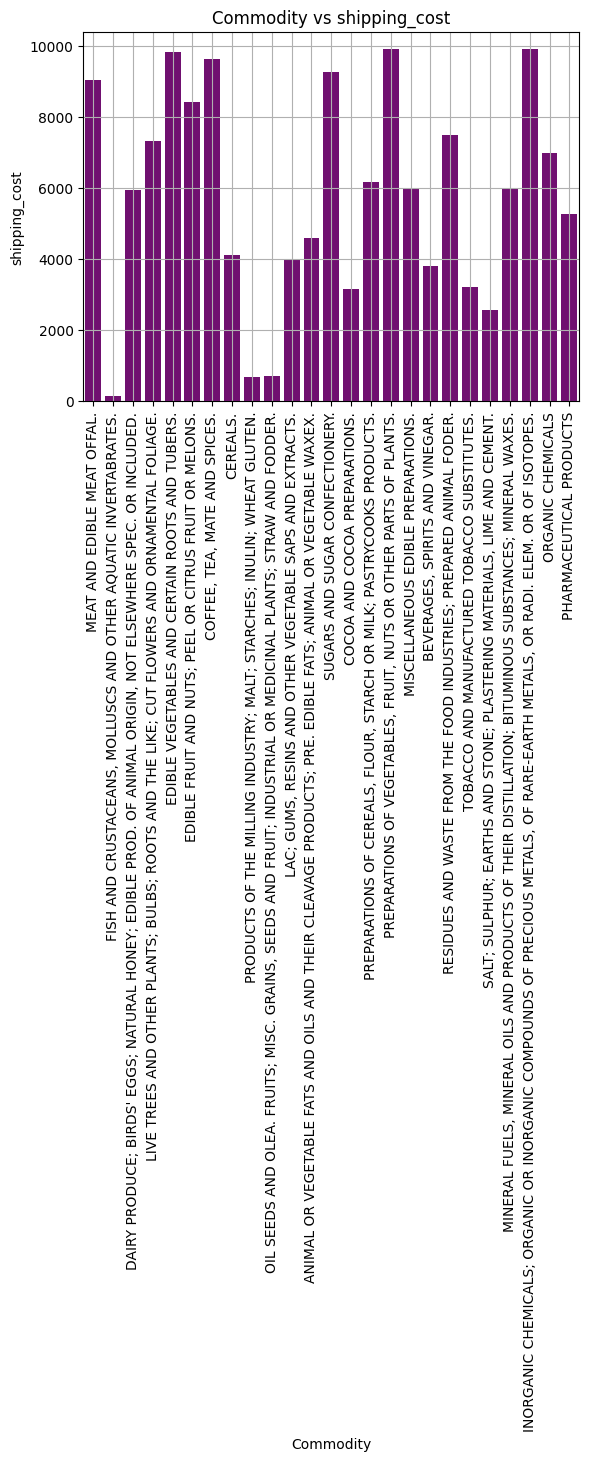

In [99]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="shipping_cost", color="purple")
plt.title("Commodity vs shipping_cost")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Shipping cost of Inorganic chemicals, Precious metals, Isotopes, parts of plants, fruits are high.

### country, shipping_cost

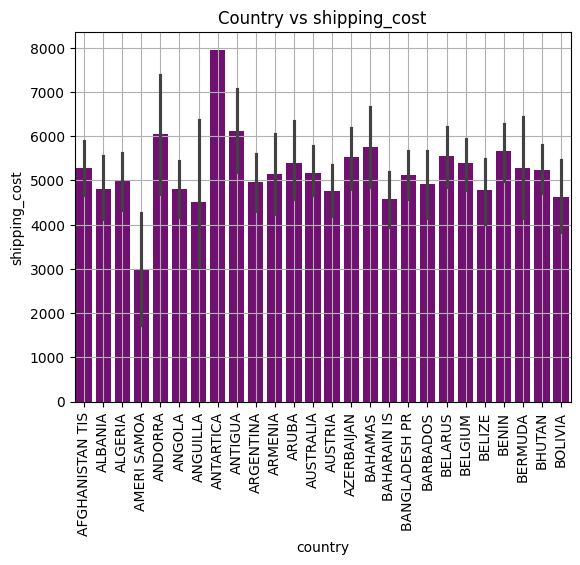

In [100]:
sns.barplot(df_trade_data.head(1500), x="country", y="shipping_cost", color="purple")
plt.title("Country vs shipping_cost")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Ameri Samoa has least shipping cost.

### type, tax

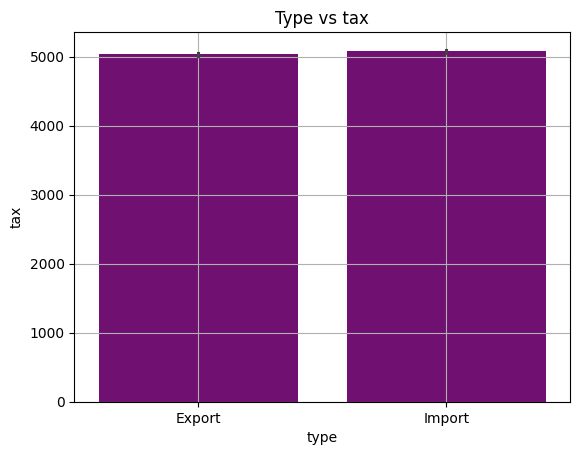

In [101]:
sns.barplot(df_trade_data, x="type", y="tax", color="purple")
plt.title("Type vs tax")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, tax

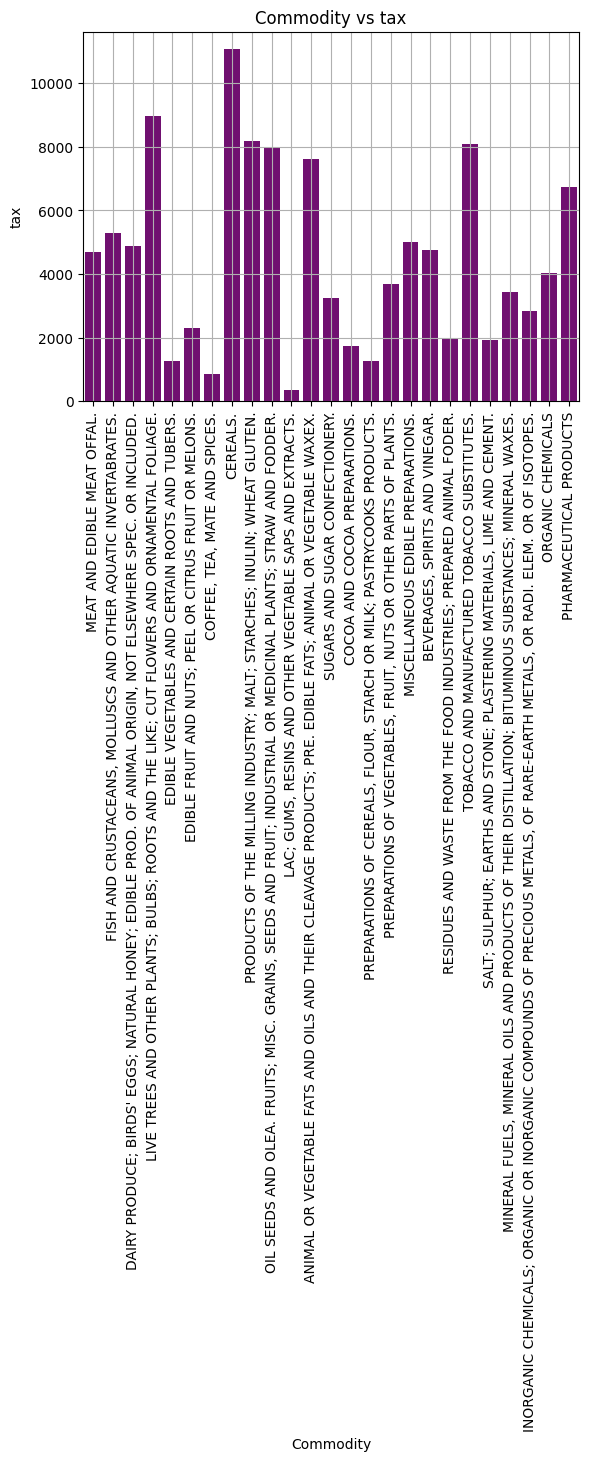

In [102]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="tax", color="purple")
plt.title("Commodity vs tax")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Tax on cereals is high.

### country, tax

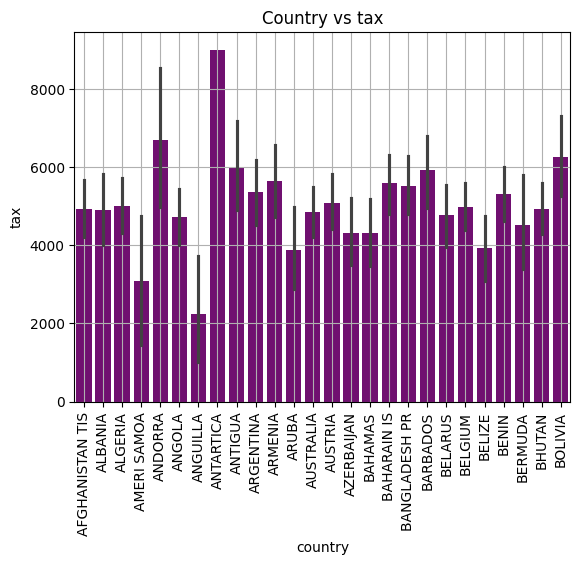

In [103]:
sns.barplot(df_trade_data.head(1500), x="country", y="tax", color="purple")
plt.title("Country vs tax")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Anguilla weighs less tax. 

### type, duty

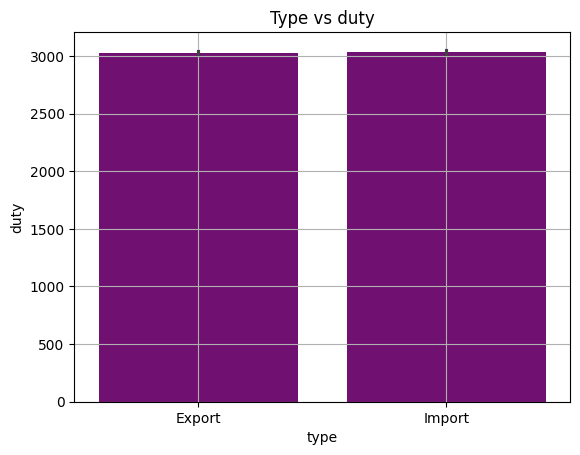

In [104]:
sns.barplot(df_trade_data, x="type", y="duty", color="purple")
plt.title("Type vs duty")
plt.grid(True)
plt.xticks(rotation=0)
plt.show()

**Interpretation**
 - The graph is quite balanced.

### Commodity, duty

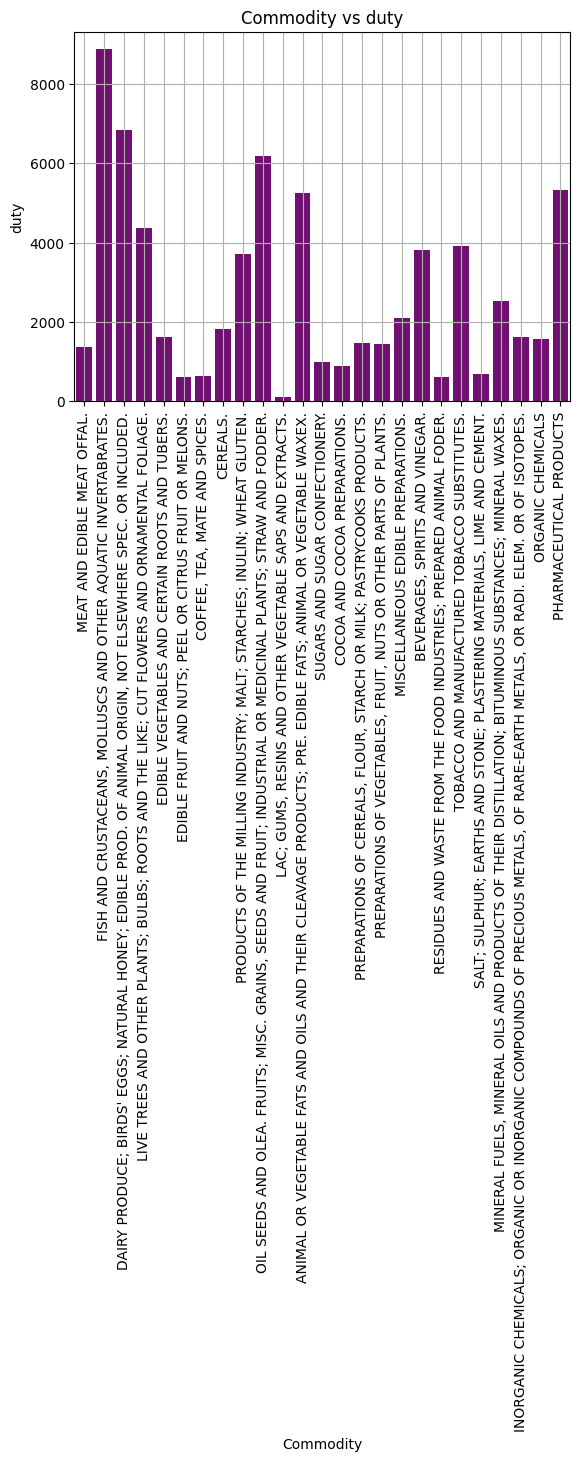

In [105]:
sns.barplot(df_trade_data.head(25), x="Commodity", y="duty", color="purple")
plt.title("Commodity vs duty")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Duty on Fish and Crustaceans, Molluscs and other Aquatic invertebrates is high.

### country, duty

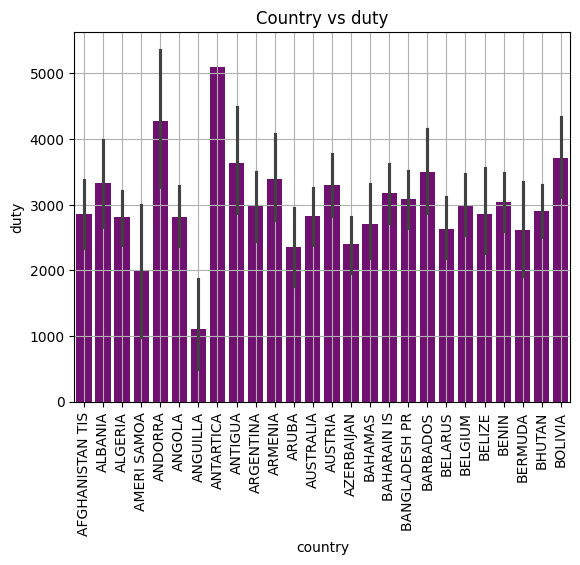

In [106]:
sns.barplot(df_trade_data.head(1500), x="country", y="duty", color="purple")
plt.title("Country vs duty")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

**Interpretation**
 - Duty on Anguilla is less.